In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, scipy.io as sio
import os, glob
from neo.io import BlackrockIO
import h5py

## Logic flow
1. preprocess (mostly notch filter) raw .mat
2.

### global variables and functions

In [2]:
patient = 2605

### lets consider example patient and channel

In [3]:
chan_mat_files = glob.glob(f'../../data/*{patient}/osort_mat/nsx2mat/*.mat'); print(f'{len(chan_mat_files)} channels: ', end='')
for chan_mat_file in sorted(chan_mat_files):    print(chan_mat_file.split('BL')[1].split('.mat')[0], end=', ')


32 channels: 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 

#samples: 57989914
sampling freq: 30000.0
signal dur: 1932.9971333333333


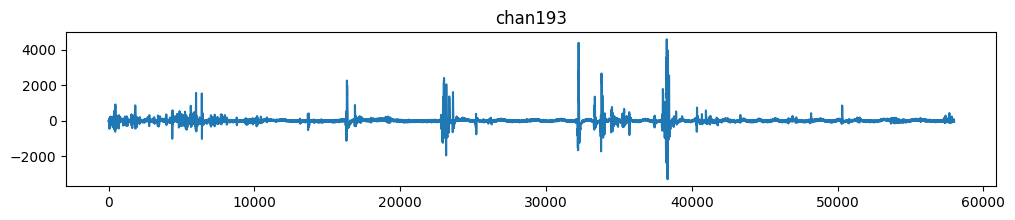

In [4]:
chanID = 193; chan_mat_file = glob.glob(f'../../data/20{patient}/osort_mat/nsx2mat/*{chanID}*.mat')[0]
with h5py.File(chan_mat_file, "r") as f:
    raw_sig = np.array(f["data"]).squeeze()
    sig_freq = float(np.array(f["MetaTags/SamplingFreq"]).squeeze())
    sig_dur = raw_sig.shape[0] / sig_freq

print(f'#samples: {raw_sig.shape[0]}\nsampling freq: {sig_freq}\nsignal dur: {sig_dur}')
plt.figure(figsize=(12,2)); plt.title(f'chan{chanID}')
every_nth = 1000
plt.plot(raw_sig[::every_nth])
plt.show()

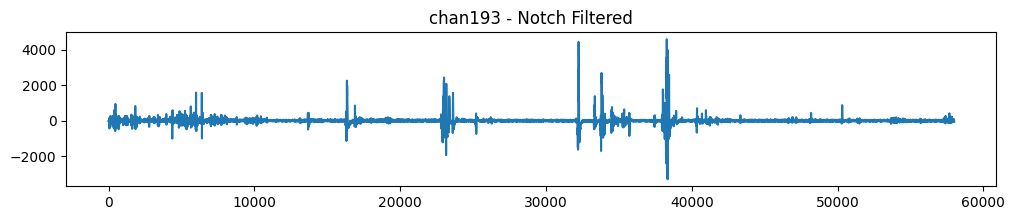

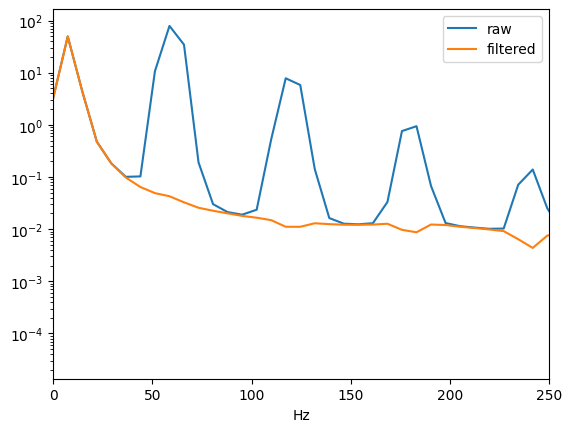

In [5]:
from scipy.signal import iirnotch, filtfilt
freqs = [60.0, 120.0, 180.0, 240.0, 300.0, 360.0, 420.0, 480.0, 540.0, 600.0]
fname = freqs[-1]

def notch_filter(data, fs, freqs=freqs, quality=60.0):
    filtered_data = data.copy()
    for freq in freqs:
        b, a = iirnotch(freq, quality, fs)
        filtered_data = filtfilt(b, a, filtered_data)
    return filtered_data

filtered_sig = notch_filter(raw_sig, sig_freq)
plt.figure(figsize=(12,2)); plt.title(f'chan{chanID} - Notch Filtered')
plt.plot(filtered_sig[::every_nth])
plt.show()

from scipy.signal import welch
f, pxx_raw = welch(raw_sig, sig_freq, nperseg=4096); f, pxx_filt = welch(filtered_sig, sig_freq, nperseg=4096)
plt.semilogy(f, pxx_raw, label='raw'); plt.semilogy(f, pxx_filt, label='filtered')
plt.xlim(0, 250); plt.xlabel('Hz')
plt.legend(); plt.show()

### great, now lets notch filter all channels and patients, and save

In [6]:
all_chan_mats = glob.glob(f'../../data/20{patient}/osort_mat/nsx2mat/*.mat')
print(len(all_chan_mats), 'total channels')

for chan_mat in sorted(all_chan_mats): # parse through all files
    chanID = int(chan_mat.split('BL')[1].split('.mat')[0])

    with h5py.File(chan_mat, "r") as f:
        raw_sig = np.array(f["data"]).squeeze()
        sig_freq = float(np.array(f["MetaTags/SamplingFreq"]).squeeze())

    filtered_sig = notch_filter(raw_sig, sig_freq)
    
    # save
    out_dir = f'../../data/20{patient}/osort_mat/nsx2mat_notch{int(fname)}/'; os.makedirs(out_dir, exist_ok=True); out_file = f'{out_dir}BL{chanID}.mat'

    # data must be row vector (1 x N) — getRawMATData tries h.data(1, from:to) first
    save = True
    if save:    sio.savemat(f'{out_dir}BL{chanID}.mat',{'data':filtered_sig.reshape(1, -1)},format='5') #v5:no HDF5, avoids matfile() MetaTags/SamplingFreq crash       
    else: print('didnt save')
    print(f'pt{patient}/chan{chanID}', end=', ')

save = False

32 total channels


pt2605/chan193, 

pt2605/chan194, 

pt2605/chan195, 

pt2605/chan196, 

...

pt2605/chan220, 

pt2605/chan221, 

pt2605/chan222, 

pt2605/chan223, 

pt2605/chan224, 